# Setup & utilities

In [1]:
# Paths you gave (edit if needed)
DWI_ROOT  = "/home/rbielski/SOOP/ds004889/acute_only/DWI_images"
MASK_ROOT = "/home/rbielski/SOOP/ds004889/acute_only/Acute_mask"

# Where to save outputs (CSV + optional split artifacts)
OUT_DIR   = "/home/rbielski/stroke_cleaned"
CSV_NAME  = "dwi_nonzero_voxel_stats.csv"

# Parallelism for faster counting
N_WORKERS = 8  # adjust if you like

# ---------------------------
# Imports & helper functions
# ---------------------------
from pathlib import Path
from collections import Counter
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import nibabel as nib

def subject_from_image_name(p: Path):
    # image example: sub-717_rec-TRACE_dwi.nii.gz
    name = p.name
    if not name.startswith("sub-") or "_rec-TRACE_dwi" not in name:
        return None
    return name.split("_rec-TRACE_dwi")[0]  # "sub-717"

def mask_path_for(subject: str, split: str):
    # mask example: sub-717_space-TRACE_desc-lesionAcute_mask.nii.gz
    return Path(MASK_ROOT) / split / f"{subject}_space-TRACE_desc-lesionAcute_mask.nii.gz"

def nonzero_count(img):
    arr = np.asanyarray(img.dataobj)
    if np.issubdtype(arr.dtype, np.floating):
        arr = np.nan_to_num(arr, nan=0.0)
    return int(np.count_nonzero(arr))

def load_row(img_path: Path, split: str):
    try:
        subject = subject_from_image_name(img_path)
        if subject is None:
            return None
        msk_path = mask_path_for(subject, split)
        if not msk_path.exists():
            return None

        img = nib.load(str(img_path))
        msk = nib.load(str(msk_path))

        ishape = tuple(int(x) for x in img.shape)
        mshape = tuple(int(x) for x in msk.shape)
        izooms = img.header.get_zooms()[:3]
        total_vox = int(np.prod(ishape))

        img_nz = nonzero_count(img)
        msk_nz = nonzero_count(msk)

        return dict(
            split=split,
            subject=subject.replace("sub-",""),
            img_path=str(img_path),
            mask_path=str(msk_path),
            shape_x=ishape[0], shape_y=ishape[1], shape_z=ishape[2],
            zoom_x=float(izooms[0]), zoom_y=float(izooms[1]), zoom_z=float(izooms[2]),
            vox_total=total_vox,
            img_nonzero=img_nz,
            img_nonzero_frac=(float(img_nz)/total_vox) if total_vox else 0.0,
            mask_nonzero=msk_nz,
            mask_nonzero_frac=(float(msk_nz)/total_vox) if total_vox else 0.0,
            shape_match=(ishape == mshape),
        )
    except Exception as e:
        print(f"[WARN] {img_path.name}: {e}")
        return None


# Scan and compute stats (no splitting yet)

In [2]:
from pathlib import Path

splits = ["train", "test"]  # change to ["train"] if you only want train for now

to_process = []
for split in splits:
    d = Path(DWI_ROOT) / split
    files = sorted(d.glob("sub-*_*TRACE_dwi.nii.gz"))
    print(f"{split}: found {len(files)} images")
    to_process.extend([(f, split) for f in files])

rows = []
with ThreadPoolExecutor(max_workers=N_WORKERS) as ex:
    futures = [ex.submit(load_row, p, s) for p, s in to_process]
    for fu in as_completed(futures):
        r = fu.result()
        if r:
            rows.append(r)

df = pd.DataFrame(rows)
print(f"Kept {len(df)} rows with matched masks.")
# Sort by non-zero voxels to quickly see the range
df = df.sort_values(["img_nonzero","vox_total","subject"], ascending=[True, True, True]).reset_index(drop=True)
df


train: found 680 images
test: found 198 images
Kept 835 rows with matched masks.


,split,subject,img_path,mask_path,shape_x,shape_y,shape_z,zoom_x,zoom_y,zoom_z,vox_total,img_nonzero,img_nonzero_frac,mask_nonzero,mask_nonzero_frac,shape_match
0,train,1356,/home/rbielski/SOOP/ds004889/acute_only/DWI_im...,/home/rbielski/SOOP/ds004889/acute_only/Acute_...,224,224,25,1.105769,1.105769,6.000000,1254400,410466,0.327221,102,0.000081,False
1,test,435,/home/rbielski/SOOP/ds004889/acute_only/DWI_im...,/home/rbielski/SOOP/ds004889/acute_only/Acute_...,224,224,25,1.105769,1.105769,6.000000,1254400,421111,0.335707,4010,0.003197,False
2,train,292,/home/rbielski/SOOP/ds004889/acute_only/DWI_im...,/home/rbielski/SOOP/ds004889/acute_only/Acute_...,224,224,25,1.105770,1.105769,6.000001,1254400,434350,0.346261,59,0.000047,False
3,test,1401,/home/rbielski/SOOP/ds004889/acute_only/DWI_im...,/home/rbielski/SOOP/ds004889/acute_only/Acute_...,224,224,23,1.105769,1.105769,6.000004,1154048,436832,0.378522,1848,0.001601,False
4,train,704,/home/rbielski/SOOP/ds004889/acute_only/DWI_im...,/home/rbielski/SOOP/ds004889/acute_only/Acute_...,224,224,25,1.105769,1.105769,6.000000,1254400,437043,0.348408,2478,0.001975,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
830,train,481,/home/rbielski/SOOP/ds004889/acute_only/DWI_im...,/home/rbielski/SOOP/ds004889/acute_only/Acute_...,480,480,26,0.522727,0.522727,5.999999,5990400,2806263,0.468460,457,0.000076,False
831,train,527,/home/rbielski/SOOP/ds004889/acute_only/DWI_im...,/home/rbielski/SOOP/ds004889/acute_only/Acute_...,480,480,27,0.522727,0.522727,6.000000,6220800,2886273,0.463971,360,0.000058,False
832,train,717,/home/rbielski/SOOP/ds004889/acute_only/DWI_im...,/home/rbielski/SOOP/ds004889/acute_only/Acute_...,512,512,26,0.491453,0.491453,6.000003,6815744,2967171,0.435341,30211,0.004433,False
833,train,1566,/home/rbielski/SOOP/ds004889/acute_only/DWI_im...,/home/rbielski/SOOP/ds004889/acute_only/Acute_...,480,480,26,0.522727,0.522727,6.000003,5990400,3022064,0.504485,26053,0.004349,False


# Inspect distributions and summary

In [3]:
# Quick numeric summary of non-zero voxel counts
if len(df):
    nz = df["img_nonzero"].to_numpy()
    print("=== Non-zero voxel summary ===")
    print(f"count: {len(nz)}")
    print(f"min  : {nz.min():,}")
    print(f"Q1   : {int(np.percentile(nz,25)):,}")
    print(f"median: {int(np.percentile(nz,50)):,}")
    print(f"Q3   : {int(np.percentile(nz,75)):,}")
    print(f"max  : {nz.max():,}")
    print(f"p10/p90: {int(np.percentile(nz,10)):,} / {int(np.percentile(nz,90)):,}")

    # Most common shapes
    shape_counts = (
        df.assign(shape=lambda x: list(zip(x.shape_x, x.shape_y, x.shape_z)))
          .groupby("shape").size().sort_values(ascending=False).head(15)
    )
    print("\nTop shapes:")
    for shape, c in shape_counts.items():
        print(f"  {shape} x {c}")

    # Save CSV of ALL rows so you can inspect in detail
    out_csv = Path(OUT_DIR) / CSV_NAME
    out_csv.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(out_csv, index=False)
    print(f"\nWrote CSV → {out_csv}")
else:
    print("No rows computed. Check paths and mask naming.")


=== Non-zero voxel summary ===
count: 835
min  : 410,466
Q1   : 549,238
median: 648,195
Q3   : 774,640
max  : 3,178,737
p10/p90: 498,807 / 1,746,206

Top shapes:
  (224, 224, 26) x 166
  (224, 224, 25) x 142
  (256, 256, 26) x 114
  (288, 288, 26) x 73
  (256, 256, 25) x 40
  (240, 240, 24) x 39
  (240, 240, 26) x 33
  (384, 384, 26) x 30
  (384, 384, 24) x 29
  (256, 256, 24) x 21
  (224, 224, 27) x 16
  (432, 432, 26) x 12
  (384, 384, 25) x 11
  (224, 224, 28) x 10
  (256, 256, 27) x 9

Wrote CSV → /home/rbielski/stroke_cleaned/dwi_nonzero_voxel_stats.csv


# Compute a quick brain mask & counts (ICV) per case


In [4]:
import numpy as np
from scipy import ndimage as ndi
from pathlib import Path
import nibabel as nib

def robust_rescale(vol, p_low=2.0, p_high=98.0):
    v = vol.astype(np.float32, copy=False)
    lo, hi = np.percentile(v[np.isfinite(v)], [p_low, p_high])
    if hi <= lo:  # degenerate
        return np.zeros_like(v, dtype=np.float32)
    v = np.clip((v - lo) / (hi - lo), 0, 1)
    return v

def otsu_threshold(vol):
    # Otsu via histogram on [0,1]
    hist, bin_edges = np.histogram(vol, bins=256, range=(0,1))
    hist = hist.astype(np.float64)
    prob = hist / (hist.sum() + 1e-12)
    omega = np.cumsum(prob)
    mu = np.cumsum(prob * (bin_edges[:-1] + bin_edges[1:]) * 0.5)
    mu_t = mu[-1]
    sigma_b2 = (mu_t*omega - mu)**2 / (omega*(1 - omega) + 1e-12)
    k = np.nanargmax(sigma_b2)
    return (bin_edges[k] + bin_edges[k+1]) * 0.5

def quick_brain_mask(img_path, central_frac=0.6, close_iters=2, open_iters=1, dilate_iters=1):
    """Return a boolean brain mask array for a DWI volume."""
    img = nib.load(str(img_path))
    vol = np.asanyarray(img.dataobj)
    if vol.ndim != 3:
        # handle 4D by taking b0/first volume if needed
        vol = vol[..., 0]

    # robust rescale and focus thresholding on central slab
    vol_r = robust_rescale(vol, 2, 98)
    z = vol_r.shape[2]
    slab = max(1, int(round(z * central_frac / 2.0)))
    z0 = (z // 2) - slab
    z1 = (z // 2) + slab
    central = vol_r[:, :, max(0, z0):min(z, z1)]
    t = otsu_threshold(central)
    bin0 = vol_r >= t

    # morphological cleanup (3D)
    bin1 = ndi.binary_closing(bin0, iterations=close_iters)
    bin1 = ndi.binary_opening(bin1, iterations=open_iters)

    # keep largest connected component (intracranial)
    lbl, n = ndi.label(bin1)
    if n == 0:
        return np.zeros_like(bin1, dtype=bool)
    sizes = ndi.sum(np.ones_like(lbl), labels=lbl, index=np.arange(1, n+1))
    largest = 1 + int(np.argmax(sizes))
    brain = lbl == largest

    # fill small 3D holes, slight dilation to catch sulci
    brain = ndi.binary_fill_holes(brain)
    if dilate_iters > 0:
        brain = ndi.binary_dilation(brain, iterations=dilate_iters)

    return brain

# Compute brain voxels per row (this will take a few minutes for the full set; try on train first if you like)
brain_counts = []
for i, r in df.iterrows():
    try:
        mask = quick_brain_mask(r["img_path"])
        brain_voxels = int(mask.sum())
    except Exception as e:
        print(f"[WARN] brain mask failed for {Path(r['img_path']).name}: {e}")
        brain_voxels = np.nan
    brain_counts.append(brain_voxels)

df["brain_voxels"] = brain_counts
df["brain_frac"]   = df["brain_voxels"] / df["vox_total"]
df.head()


,split,subject,img_path,mask_path,shape_x,shape_y,shape_z,zoom_x,zoom_y,zoom_z,vox_total,img_nonzero,img_nonzero_frac,mask_nonzero,mask_nonzero_frac,shape_match,brain_voxels,brain_frac
0,train,1356,/home/rbielski/SOOP/ds004889/acute_only/DWI_im...,/home/rbielski/SOOP/ds004889/acute_only/Acute_...,224,224,25,1.105769,1.105769,6.000000,1254400,410466,0.327221,102,0.000081,False,144140,0.114908
1,test,435,/home/rbielski/SOOP/ds004889/acute_only/DWI_im...,/home/rbielski/SOOP/ds004889/acute_only/Acute_...,224,224,25,1.105769,1.105769,6.000000,1254400,421111,0.335707,4010,0.003197,False,160421,0.127887
2,train,292,/home/rbielski/SOOP/ds004889/acute_only/DWI_im...,/home/rbielski/SOOP/ds004889/acute_only/Acute_...,224,224,25,1.105770,1.105769,6.000001,1254400,434350,0.346261,59,0.000047,False,180220,0.143670
3,test,1401,/home/rbielski/SOOP/ds004889/acute_only/DWI_im...,/home/rbielski/SOOP/ds004889/acute_only/Acute_...,224,224,23,1.105769,1.105769,6.000004,1154048,436832,0.378522,1848,0.001601,False,185840,0.161033
4,train,704,/home/rbielski/SOOP/ds004889/acute_only/DWI_im...,/home/rbielski/SOOP/ds004889/acute_only/Acute_...,224,224,25,1.105769,1.105769,6.000000,1254400,437043,0.348408,2478,0.001975,False,161035,0.128376


# Inspect “brainness” and compare to non-zero counts

In [5]:
print("=== Intracranial volume (ICV) summary (brain_voxels) ===")
ok = df["brain_voxels"].notna()
bv = df.loc[ok, "brain_voxels"].to_numpy(dtype=np.int64)
if len(bv):
    pct = lambda q: int(np.percentile(bv, q))
    print(f"count: {len(bv)}")
    print(f"min/max: {bv.min():,} / {bv.max():,}")
    print(f"Q1/median/Q3: {pct(25):,} / {pct(50):,} / {pct(75):,}")

    print("\n=== Brain fraction of FOV (brain_voxels / total) ===")
    bf = df.loc[ok, "brain_frac"].to_numpy(dtype=float)
    print(f"mean: {bf.mean():.3f},  std: {bf.std():.3f}")
    print(f"p10/50/90: {np.percentile(bf,10):.3f} / {np.percentile(bf,50):.3f} / {np.percentile(bf,90):.3f}")

    # How different is non-zero vs brain?
    import numpy as np
    nz = df.loc[ok, "img_nonzero"].to_numpy(dtype=np.int64)
    diff = (nz - bv) / df.loc[ok, "vox_total"].to_numpy()
    print("\n=== Non-zero vs Brain (fraction of total) ===")
    print(f"mean(nz - brain)/total: {diff.mean():.3f}  (positive = non-zero counts more than brain)")
else:
    print("No brain_voxels computed; check previous cell.")

# Optional: view a few edge cases
print("\nExamples (lowest brain_frac):")
display(
    df.sort_values("brain_frac").head(10)[
        ["subject","split","brain_voxels","brain_frac","img_nonzero","vox_total","shape_x","shape_y","shape_z"]
    ]
)

print("\nExamples (highest brain_frac):")
display(
    df.sort_values("brain_frac", ascending=False).head(10)[
        ["subject","split","brain_voxels","brain_frac","img_nonzero","vox_total","shape_x","shape_y","shape_z"]
    ]
)


=== Intracranial volume (ICV) summary (brain_voxels) ===
count: 835
min/max: 144,140 / 1,120,448
Q1/median/Q3: 214,979 / 248,371 / 307,741

=== Brain fraction of FOV (brain_voxels / total) ===
mean: 0.165,  std: 0.022
p10/50/90: 0.139 / 0.165 / 0.193

=== Non-zero vs Brain (fraction of total) ===
mean(nz - brain)/total: 0.263  (positive = non-zero counts more than brain)

Examples (lowest brain_frac):


,subject,split,brain_voxels,brain_frac,img_nonzero,vox_total,shape_x,shape_y,shape_z
771,1073,train,177575,0.046318,1828139,3833856,384,384,26
421,1655,train,219084,0.101590,650339,2156544,288,288,26
680,516,test,226505,0.105031,840144,2156544,288,288,26
551,655,train,241893,0.112167,730379,2156544,288,288,26
557,1574,train,244102,0.113191,732236,2156544,288,288,26
473,277,train,246355,0.114236,679340,2156544,288,288,26
0,1356,train,144140,0.114908,410466,1254400,224,224,25
487,1673,train,247851,0.114930,689261,2156544,288,288,26
408,244,train,248371,0.115171,642943,2156544,288,288,26
253,334,train,197601,0.115967,571190,1703936,256,256,26



Examples (highest brain_frac):


,subject,split,brain_voxels,brain_frac,img_nonzero,vox_total,shape_x,shape_y,shape_z
716,1252,test,420336,0.246685,1029855,1703936,256,256,26
808,1660,train,805539,0.227621,2089454,3538944,384,384,24
553,1291,train,308886,0.224439,730751,1376256,256,256,21
753,751,test,787349,0.222481,1758218,3538944,384,384,24
454,993,train,286321,0.219474,670361,1304576,224,224,26
776,714,train,761390,0.215146,1865793,3538944,384,384,24
482,248,train,280474,0.214992,683464,1304576,224,224,26
591,989,test,301116,0.214328,751774,1404928,224,224,28
676,1330,train,349935,0.213583,834808,1638400,256,256,25
673,1476,train,349473,0.213301,828679,1638400,256,256,25


Lowest brain_frac examples:


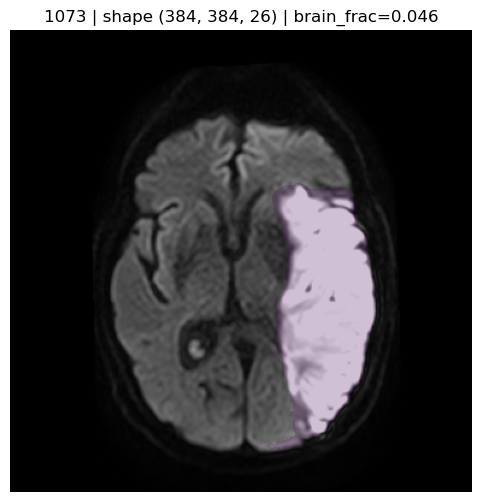

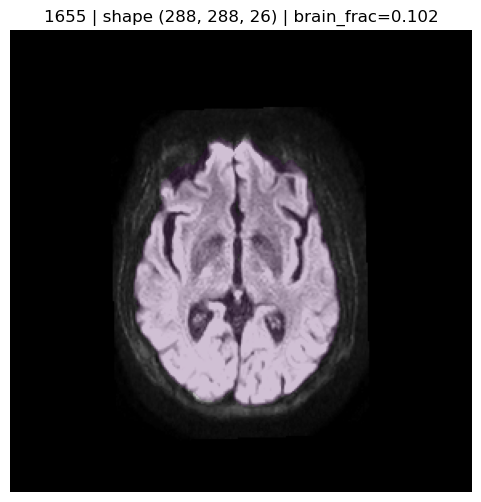

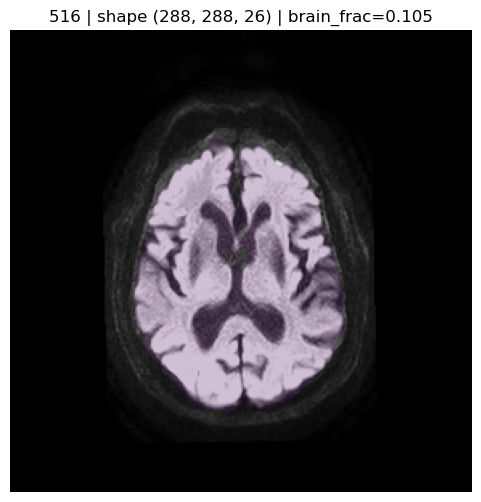

Highest brain_frac examples:


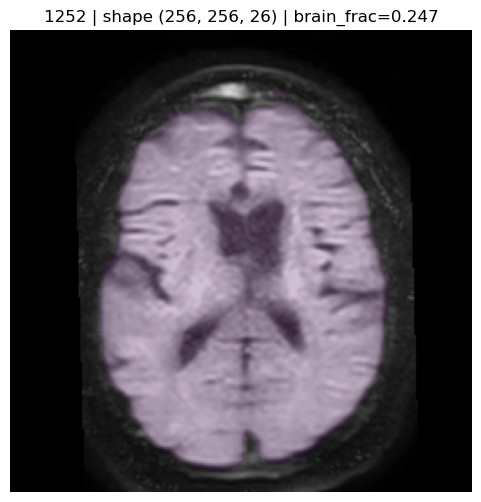

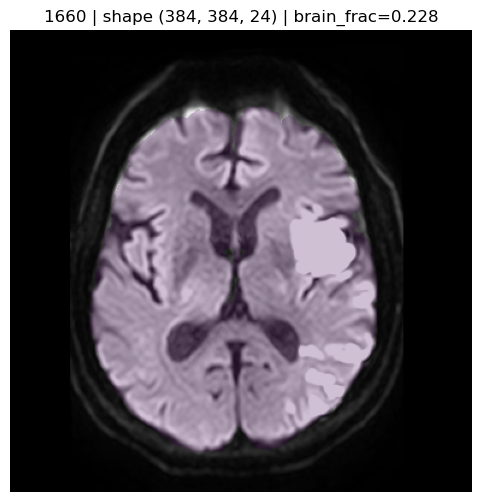

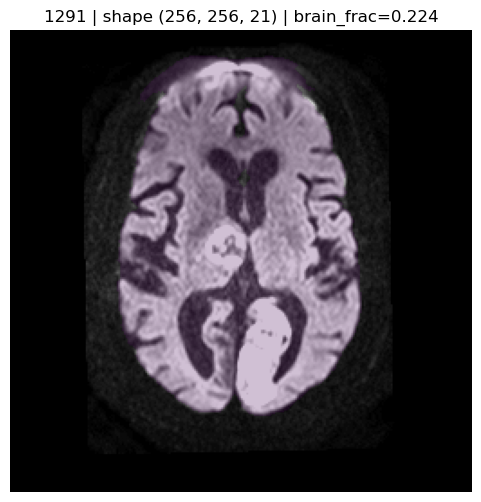

In [6]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

def show_overlay(row, z_slice='mid'):
    img = nib.load(row["img_path"])
    vol = np.asanyarray(img.dataobj)
    if vol.ndim == 4: vol = vol[...,0]
    z = vol.shape[2]
    k = z//2 if z_slice=='mid' else (0 if z_slice=='min' else z-1)

    # reuse mask via threshold from earlier quick_brain_mask to keep consistent
    from scipy import ndimage as ndi
    def robust_rescale(v, p_lo=2, p_hi=98):
        lo, hi = np.percentile(v[np.isfinite(v)], [p_lo, p_hi])
        v = np.clip((v-lo)/(hi-lo+1e-12), 0, 1)
        return v
    v = robust_rescale(vol)
    # simple Otsu on central slab
    slab = max(1, int(0.3*z))
    c0, c1 = max(0, z//2 - slab//2), min(z, z//2 + slab//2)
    t = np.histogram(v[:,:,c0:c1], bins=256, range=(0,1))[1]
    hist,_ = np.histogram(v[:,:,c0:c1], bins=256, range=(0,1))
    prob = hist / (hist.sum() + 1e-12)
    omega = np.cumsum(prob)
    centers = (t[:-1]+t[1:])*0.5
    mu = np.cumsum(prob*centers)
    sigma_b2 = (mu[-1]*omega - mu)**2 / (omega*(1-omega)+1e-12)
    thr = centers[np.nanargmax(sigma_b2)]
    m = v>=thr
    m = ndi.binary_closing(m, iterations=2)
    m = ndi.binary_opening(m, iterations=1)
    lbl, n = ndi.label(m)
    if n>0:
        sizes = ndi.sum(np.ones_like(lbl), labels=lbl, index=np.arange(1,n+1))
        m = lbl==(1+np.argmax(sizes))
        m = ndi.binary_fill_holes(m)
        m = ndi.binary_dilation(m, iterations=1)
    else:
        m = np.zeros_like(m)

    plt.figure(figsize=(6,6))
    plt.imshow(v[:,:,k].T, origin='lower', cmap='gray')
    # overlay contour
    cnt = m[:,:,k].T.astype(float)
    cnt[cnt==0] = np.nan
    plt.imshow(cnt, origin='lower', alpha=0.25)  # default colormap overlay
    plt.title(f"{row['subject']} | shape {vol.shape} | brain_frac={row['brain_frac']:.3f}")
    plt.axis('off')
    plt.show()

print("Lowest brain_frac examples:")
for _, r in df.sort_values("brain_frac").head(3).iterrows():
    show_overlay(r)

print("Highest brain_frac examples:")
for _, r in df.sort_values("brain_frac", ascending=False).head(3).iterrows():
    show_overlay(r)
